# Figure 1A

In [10]:
import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
from cellpose import models
from cellpose.utils import stitch3D

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)
# segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))[frame, :]
# print(segmentation.shape)


# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\20260511 CARE BSc\Train Low segmenter\models\low_input"
#     )
# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_high_quality_model"
#     )


# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 0.3)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
viewer.add_image(cropped[:, y_half, x_half], contrast_limits=contrast, scale=scale)
viewer.add_labels(cp[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
viewer.add_labels(nuclogic[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_labels(cp, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 58 breaks.
    Iteration 2: Made 22 breaks.
    Iteration 3: Made 16 breaks.
    Iteration 4: Made 3 breaks.
Finding touching cell pairs...
Found 347 pairs of touching cells.
Splitted 70 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 10 small cells, and removed 15 cells without suitable neighbors.
Final stitched mask has 385 cells.
slice(0, 147, None) slice(0, 290, None

Figure 2

In [1]:
# Figure 2A

import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
import scipy.ndimage

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
from utils.expand_mask import expand_mask_3d

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)

# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 2)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)

selected_mask_cp = cp == 167  # show only the mask for cell 174
selected_mask_cp = np.where(selected_mask_cp, cp, 0)  # create a masked image where only the selected cell is visible
# cropped_masked = expand_mask_3d(selected_mask_cp, dilation_size_um = 2, voxel_size=scale)  # dilate the mask to make it more visible
# cropped_masked = np.where(cropped_masked, cropped, 0)  # create a masked image where only the selected cell is visible
selected_ids_nuclogic = [166, 336]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible
# target_z = np.where(selected_mask_nuclogic)[0].min() + 5
# nuclogic_display = nuclogic.copy()
# # replace both cell IDs only in that single slice
# nuclogic_display[target_z][np.isin(nuclogic_display[target_z], [166, 336])] = 166


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
# viewer.reset_view()
# viewer.camera.center = (83.24123779650657, 96.3297331771258, 59.20690029145916)
# viewer.camera.angles = (180, 0.6526549938471702, 0.413991687612314)
# viewer.camera.zoom = 12.308777811410637
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# # make scale bar visible
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# #toggle grid mode on
# viewer.grid.enabled = True
# viewer.theme = 'light'

# # save screenshot
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# napari.run()
# # viewer.screenshot(path=os.path.join(output_directory, "2A.png"), canvas_only=True, scale = 2)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 0.9032813846033362, 0.7951773315819103, 1.2251157407407407, 1.1290666666666669, 0.8769322235434006, 1.387234809242827, 0.8830795748348177, 0.8891657766702267, 0.8779217558435117, 0]
  Intensity break scores: [0, 0.8492980268904382, 0.91223470190151, 0.8789276647534391, 0.9990466362153788, 1.387835958498404, 1.022743029860302, 0.9343847063029113, 1.046150241330675, 1.

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\standardize_color.py:91: UserWarning: Empty string detected. Returning black instead.
  warnings.warn(


<Labels layer 'selected_mask_cp' at 0x1d900553a90>

In [2]:
# print the most bottom nonzero slice of the selected mask to check if the bottom part of the cell is still visible
print("Most bottom nonzero slice of the selected mask:")
print(np.where(selected_mask_nuclogic)[0].min())

Most bottom nonzero slice of the selected mask:
28


In [ ]:
# Figure 2A_bottom
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "2A_bottom.png"), canvas_only=True, scale = 3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [2]:
# Figure 2b final
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)

selected_ids_nuclogic = [166, 343]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
# selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible

viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
nuclogic2 = stitch_3d(nuclogic, cropped, breaking_threshold = 2)
viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(selected_mask_nuclogic, scale=scale, colormap={0: "", 166: "magenta", 343: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "2B_final.png"), canvas_only=True, scale = 3)

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2213 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 364 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 2.3714285714285714, 0.8465608465608466, 0.8779213238496153, 0.9096137152777779, 1.0520833333333335, 0.8469757866875796, 0.8603703703703703, 0]
  Intensity break scores: [0, 0.9282447968593451, 1.0870938958260137, 1.217307202571666, 0.996838532179134, 0.8590281509355322, 0.9518647819844411, 1.1132058805582201, 0]
  Line break scores (up): [0.         0.         1.15613345 3.80633368 2.32554158 0.21497982
 0.41075812 0.19655939 0.0941902 ]
  Line distances (up): [0.57806672 1.15613345 0.57806672 3.80633368 4.70905905 5.3968046
 6.49530828 7.79037133 9.17962459]
  Line break scores (down): [0.         1.16928662 1.79121567 0.94175093 0.13594289 

array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [53]:
# Function that will crop a movie based on an existing XY max projection using a SAM model

import tifffile
import pandas as pd
import numpy as np
from libpysal.weights import KNN
from esda.moran import Moran
from imaris_ims_file_reader.ims import ims
from PIL import Image
import scipy.ndimage as ndimage
import cv2


from utils.offset_image import offset_image
from utils.pad_to_shape import pad_to_shape


import os, shutil, tempfile


def old_crop(
    proj_XY,
    input_file,
    model,
    nuclei=2,
    name="projXY_tracked",
):

    # Convert movie to 8 bit for meta SAM
    # nuclei may be a list (single or dual); always max-project over channel axis -> (T, H, W)
    nuclei_list = nuclei if isinstance(nuclei, list) else [nuclei]
    proj_XY_nuclei = np.max(proj_XY[:, nuclei_list, :, :], axis=1)
    print(f"proj_XY_nuclei shape: {proj_XY_nuclei.shape}")
    proj_XY_8bit = ((proj_XY_nuclei / np.percentile(proj_XY_nuclei, 99.9)) * 255).astype(np.uint8)

    all_masks = old_segment_organoid(proj_XY_8bit, model)

    # Dilate the masks by 12 pixels to ensure the organoid is fully in there
    new_masks = []
    for _, mask in enumerate(all_masks):
        mask = ndimage.binary_dilation(mask, iterations=12)
        new_masks.append(mask)
    new_masks = np.stack(new_masks, axis=0).astype(np.uint16)

    # Expand masks to match channel dimension: (T, Y, X) -> (T, C, Y, X)
    new_masks = new_masks[:, np.newaxis, :, :]  # Add channel axis
    new_masks = np.repeat(new_masks, proj_XY.shape[1], axis=1)

    # Create new movie that only has the tracked organoid
    organoid_only = np.where(new_masks, proj_XY, 0)

    return organoid_only
    # Save this tracked movie to the output folder
    tifffile.imwrite(
        os.path.join(
            os.path.dirname(input_file),
            f"{name}_projXY_tracked.tif",
        ),
        organoid_only,
        imagej=True,
        metadata={"axes": "TCYX"},
        compression="zlib",
        compressionargs={"level": 8},
    )

    # Load in the input image, which is either a ims or tiff
    if input_file.endswith(".ims"):
        movie = ims(input_file)  # T,C,Z,Y,X
    elif input_file.endswith(".tif"):
        movie = tifffile.imread(input_file)  # T,Z,C,Y,X
        movie = np.transpose(movie, (0, 2, 1, 3, 4))  # T,C,Z,Y,X

    timepoints = proj_XY.shape[0]

    cropped_movie = []
    max_dims = [0, 0, 0, 0]

    # Loop over every frame in the movie to crop that frame.
    for frame in range(timepoints):

            maskXY = np.max(organoid_only[frame, nuclei], axis=0) > 0
            coordsXY = np.where(maskXY)

            # Adjust cropping limits based on XY projection, creating a bounding box around the organoid
            if coordsXY[0].size > 0:
                row_min, row_max = (
                    np.min(coordsXY[0]),
                    np.max(coordsXY[0]) + 1,
                )
                col_min, col_max = (
                    np.min(coordsXY[1]),
                    np.max(coordsXY[1]) + 1,
                )

            # Get the frame of the movie — always max-project over nuclei channels (handles 1 or 2)
            nuclei_list = nuclei if isinstance(nuclei, list) else [nuclei]
            ref = np.max(
                np.stack(
                    [
                        movie[frame, ch, :, row_min:row_max, col_min:col_max]
                        for ch in nuclei_list
                    ]
                ),
                axis=0,
            )

            # Get a bounding box cropped version of the organoid
            ref_crop = maskXY[row_min:row_max, col_min:col_max]

            # In this bounding box image, create the Z axis of the same dimensions of the original movie
            ref_expanded = ref_crop[np.newaxis, :, :]
            ref_expanded = np.repeat(ref_expanded, ref.shape[0], axis=0)

            # Use the this XYZ mask on the original movie to crop as both a bounding box and to make all pixels (corners) where there is no organoid actually black
            ref_masked = np.where(ref_expanded > 0, ref, 0).astype(np.uint16)

            # Make an max XZ projection that we will use to see what Z slices are important
            XZ = np.max(ref_masked, axis=1)

            # Apply offset to enhance contrast and make background and signal more distinct
            XZ = offset_image(XZ, type="median")

            z_list = []
            moran_values = []  # Collect Moran’s I for all rows

            # Step 1: Calculate Moran's I for each row
            for idx, row in enumerate(XZ):
                if np.std(row) == 0:
                    moran_values.append((idx, 0))
                    continue
                coords = np.arange(len(row)).reshape(-1, 1)
                w_1d = KNN.from_array(coords, k=2)
                moran = Moran(row, w_1d)
                if not np.isnan(
                    moran.I
                ):  # Make sure this value is not NA, which can happen in truly background / random data
                    moran_values.append((idx, moran.I))  # store both index and value
                else:
                    moran_values.append((idx, 0))

            # Step 2: Calculate dynamic threshold based on max moran I value found
            max_moran = max(val for _, val in moran_values)
            threshold = 0.4 * max_moran

            # Step 3: Filter Z slices using threshold
            z_list = [idx for idx, val in moran_values if val >= threshold]

            z_vals_sorted = sorted(set(z_list))
            max_block = []
            current_block = [z_vals_sorted[0]]

            for i in range(1, len(z_vals_sorted)):
                if z_vals_sorted[i] - z_vals_sorted[i - 1] <= 6:
                    current_block.append(z_vals_sorted[i])
                else:
                    if len(current_block) > len(max_block):
                        max_block = current_block
                    current_block = [z_vals_sorted[i]]

            # Final check in case the longest block ends the loop
            if len(current_block) > len(max_block):
                max_block = current_block

            slice_min = max(min(max_block) - 2, 0)
            slice_max = min(max(max_block) + 2, ref.shape[0])

            # This time, crop the frame of the movie on all channels using corrext XYZ
            cropped_image = movie[
                frame, :, slice_min:slice_max, row_min:row_max, col_min:col_max
            ]
            # ims reader squeezes C=1 to 3D (Z,Y,X); restore to (C,Z,Y,X)
            if cropped_image.ndim == 3:
                cropped_image = cropped_image[np.newaxis, :, :, :]

            # On this cropped frame, we again need to make it so that the pixels in the corners where no organoid is are actually black
            mask_crop = maskXY[
                row_min:row_max, col_min:col_max
            ]  # shape: (Y_crop, X_crop)
            # Expand mask to 4D: (C, Z, Y_crop, X_crop)
            mask_expanded = mask_crop[np.newaxis, np.newaxis, :, :]
            # Repeat over C and Z to match cropped_image shape
            mask_expanded = np.repeat(
                mask_expanded, cropped_image.shape[0], axis=0
            )  # C
            mask_expanded = np.repeat(
                mask_expanded, cropped_image.shape[1], axis=1
            )  # Z
            # Apply the mask
            cropped_image_masked = np.where(mask_expanded, cropped_image, 0).astype(
                np.uint16
            )
            cropped_image_masked = np.transpose(
                cropped_image_masked, (1, 0, 2, 3)
            )  # Z C Y X for tiff

            cropped_movie.append(cropped_image_masked)
            for i in range(4):
                max_dims[i] = max(max_dims[i], cropped_image_masked.shape[i])

    cropped_movie = [pad_to_shape(stack, max_dims) for stack in cropped_movie]
    cropped_movie = np.stack(cropped_movie, axis=0)

    return cropped_movie


def old_get_coords(movie):
    first_frame = movie[0]
    # Normalize and convert to 8-bit
    frame = ((first_frame / first_frame.max()) * 255).astype(np.uint8)
    frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

    # Apply threshold (you can tweak the value)
    median = np.median(frame)
    _, binary_mask = cv2.threshold(frame, median + 5, 255, cv2.THRESH_BINARY)

    binary_mask = ndimage.binary_dilation(binary_mask, iterations=10)
    filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
    num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
        filled_mask
    )

    center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

    df = {
        "label": np.arange(1, num_labels),
        "area": stats_array[1:, cv2.CC_STAT_AREA],
        "centroid": [c for c in centroids[1:]],  # keep as array
    }

    df = pd.DataFrame(df)
    # Compute distances to center
    df["distance_to_center"] = df["centroid"].apply(
        lambda c: np.linalg.norm(center - c)
    )

    # Filter and select
    filtered_df = df[df["area"] > 3000]
    closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]
    selected_label = closest["label"]

    # Create a binary mask for the selected label
    selected_mask = (labels == selected_label).astype(np.uint8)

    eroded_mask = ndimage.binary_erosion(selected_mask, iterations=20).astype(np.uint8)

    # Get coordinates from the eroded mask
    coords = np.column_stack(np.where(eroded_mask > 0))  # shape: (N, 2) with (row, col)

    sampled_points = coords[np.random.choice(len(coords), 5, replace=False)][:, ::-1]
    selected_centroid = closest["centroid"]
    selected_centroid = np.array(
        [[int(selected_centroid[0]), int(selected_centroid[1])]], dtype=np.int32
    )

    combined_points = np.vstack([sampled_points, selected_centroid])

    return combined_points


def old_segment_organoid(proj_XY_8bit, model):

    # Temporary directory for saving frames
    temp_dir = tempfile.mkdtemp()

    # Itterate over movie frames
    for i, frame in enumerate(proj_XY_8bit):
        # Convert image to RGB grayscale image
        if frame.ndim == 2:
            frame = np.stack([frame] * 3, axis=-1)

        # Normalize the frame to 0-255 range
        frame = (frame / frame.max() * 255).astype(np.uint8)

        # Save the frame as a JPEG image
        Image.fromarray(frame).save(os.path.join(temp_dir, f"{i:05d}.jpeg"))

    # Get inference state
    inference_state = model.init_state(temp_dir)

    # Calculate center point where organoid should be
    coords = old_get_coords(proj_XY_8bit)

    labels = np.ones(len(coords))
    _, object_ids, mask_logits = model.add_new_points(
        inference_state=inference_state,
        frame_idx=0,
        obj_id=1,
        points=coords,
        labels=labels,
    )

    # Get the masks of the organoid
    all_masks = []
    for frame_idx, object_ids, mask_logits in model.propagate_in_video(inference_state):
        masks = (mask_logits > 0.0).cpu().numpy()  # shape: (N, X, H, W)
        N, X, H, W = masks.shape
        masks = masks.reshape(N * X, H, W)
        all_masks.append(masks)

    shutil.rmtree(temp_dir)

    all_masks = np.stack(all_masks, axis=0)  # shape: (T, C, Y, X)
    all_masks = all_masks[:, 0]  # T Y X

    return all_masks


In [64]:
# Function that will crop a movie based on an existing XY max projection using a SAM model

import tifffile
import pandas as pd
import numpy as np
from libpysal.weights import KNN
from esda.moran import Moran
from imaris_ims_file_reader.ims import ims
from PIL import Image
import scipy.ndimage as ndimage
import cv2
from utils.offset_image import offset_image
from utils.pad_to_shape import pad_to_shape


import os, shutil, tempfile


def crop(
    proj_XY,
    input_file,
    model,
    nuclei=2,
    name="projXY_tracked",
):

    # Convert movie to 8 bit for meta SAM
    # nuclei may be a list (single or dual); always max-project over channel axis -> (T, H, W)
    nuclei_list = nuclei if isinstance(nuclei, list) else [nuclei]
    proj_XY_nuclei = np.max(proj_XY[:, nuclei_list, :, :], axis=1)
    proj_XY_8bit = ((proj_XY_nuclei / np.percentile(proj_XY_nuclei, 99.9)) * 255).astype(np.uint8)

    all_masks = segment_organoid(proj_XY_8bit, model)

    # Dilate the masks by 12 pixels to ensure the organoid is fully in there
    new_masks = []
    for _, mask in enumerate(all_masks):
        mask = ndimage.binary_dilation(mask, iterations=12)
        new_masks.append(mask)
    new_masks = np.stack(new_masks, axis=0).astype(np.uint16)

    # Expand masks to match channel dimension: (T, Y, X) -> (T, C, Y, X)
    new_masks = new_masks[:, np.newaxis, :, :]  # Add channel axis
    new_masks = np.repeat(new_masks, proj_XY.shape[1], axis=1)

    # Create new movie that only has the tracked organoid
    organoid_only = np.where(new_masks, proj_XY, 0)

    return organoid_only
    # # Save this tracked movie to the output folder
    # tifffile.imwrite(
    #     os.path.join(
    #         os.path.dirname(input_file),
    #         f"{name}_projXY_tracked.tif",
    #     ),
    #     organoid_only,
    #     imagej=True,
    #     metadata={"axes": "TCYX"},
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # # Load in the input image, which is either a ims or tiff
    # if input_file.endswith(".ims"):
    #     movie = ims(input_file)  # T,C,Z,Y,X
    # elif input_file.endswith(".tif"):
    #     movie = tifffile.imread(input_file)  # T,Z,C,Y,X
    #     movie = np.transpose(movie, (0, 2, 1, 3, 4))  # T,C,Z,Y,X

    # timepoints = proj_XY.shape[0]

    # cropped_movie = []
    # max_dims = [0, 0, 0, 0]

    # # Loop over every frame in the movie to crop that frame.
    # for frame in range(timepoints):

    #         maskXY = np.max(organoid_only[frame, nuclei], axis=0) > 0
    #         coordsXY = np.where(maskXY)

    #         # Adjust cropping limits based on XY projection, creating a bounding box around the organoid
    #         if coordsXY[0].size > 0:
    #             row_min, row_max = (
    #                 np.min(coordsXY[0]),
    #                 np.max(coordsXY[0]) + 1,
    #             )
    #             col_min, col_max = (
    #                 np.min(coordsXY[1]),
    #                 np.max(coordsXY[1]) + 1,
    #             )

    #         # Get the frame of the movie — always max-project over nuclei channels (handles 1 or 2)
    #         nuclei_list = nuclei if isinstance(nuclei, list) else [nuclei]
    #         ref = np.max(
    #             np.stack(
    #                 [
    #                     movie[frame, ch, :, row_min:row_max, col_min:col_max]
    #                     for ch in nuclei_list
    #                 ]
    #             ),
    #             axis=0,
    #         )

    #         # Get a bounding box cropped version of the organoid
    #         ref_crop = maskXY[row_min:row_max, col_min:col_max]

    #         # In this bounding box image, create the Z axis of the same dimensions of the original movie
    #         ref_expanded = ref_crop[np.newaxis, :, :]
    #         ref_expanded = np.repeat(ref_expanded, ref.shape[0], axis=0)

    #         # Use the this XYZ mask on the original movie to crop as both a bounding box and to make all pixels (corners) where there is no organoid actually black
    #         ref_masked = np.where(ref_expanded > 0, ref, 0).astype(np.uint16)

    #         # Make an max XZ projection that we will use to see what Z slices are important
    #         XZ = np.max(ref_masked, axis=1)

    #         # Apply offset to enhance contrast and make background and signal more distinct
    #         XZ = offset_image(XZ, type="median")

    #         z_list = []
    #         moran_values = []  # Collect Moran’s I for all rows

    #         # Step 1: Calculate Moran's I for each row
    #         for idx, row in enumerate(XZ):
    #             if np.std(row) == 0:
    #                 moran_values.append((idx, 0))
    #                 continue
    #             coords = np.arange(len(row)).reshape(-1, 1)
    #             w_1d = KNN.from_array(coords, k=2)
    #             moran = Moran(row, w_1d)
    #             if not np.isnan(
    #                 moran.I
    #             ):  # Make sure this value is not NA, which can happen in truly background / random data
    #                 moran_values.append((idx, moran.I))  # store both index and value
    #             else:
    #                 moran_values.append((idx, 0))

    #         # Step 2: Calculate dynamic threshold based on max moran I value found
    #         max_moran = max(val for _, val in moran_values)
    #         threshold = 0.4 * max_moran

    #         # Step 3: Filter Z slices using threshold
    #         z_list = [idx for idx, val in moran_values if val >= threshold]

    #         z_vals_sorted = sorted(set(z_list))
    #         max_block = []
    #         current_block = [z_vals_sorted[0]]

    #         for i in range(1, len(z_vals_sorted)):
    #             if z_vals_sorted[i] - z_vals_sorted[i - 1] <= 6:
    #                 current_block.append(z_vals_sorted[i])
    #             else:
    #                 if len(current_block) > len(max_block):
    #                     max_block = current_block
    #                 current_block = [z_vals_sorted[i]]

    #         # Final check in case the longest block ends the loop
    #         if len(current_block) > len(max_block):
    #             max_block = current_block

    #         slice_min = max(min(max_block) - 2, 0)
    #         slice_max = min(max(max_block) + 2, ref.shape[0])

    #         # This time, crop the frame of the movie on all channels using corrext XYZ
    #         cropped_image = movie[
    #             frame, :, slice_min:slice_max, row_min:row_max, col_min:col_max
    #         ]
    #         # ims reader squeezes C=1 to 3D (Z,Y,X); restore to (C,Z,Y,X)
    #         if cropped_image.ndim == 3:
    #             cropped_image = cropped_image[np.newaxis, :, :, :]

    #         # On this cropped frame, we again need to make it so that the pixels in the corners where no organoid is are actually black
    #         mask_crop = maskXY[
    #             row_min:row_max, col_min:col_max
    #         ]  # shape: (Y_crop, X_crop)
    #         # Expand mask to 4D: (C, Z, Y_crop, X_crop)
    #         mask_expanded = mask_crop[np.newaxis, np.newaxis, :, :]
    #         # Repeat over C and Z to match cropped_image shape
    #         mask_expanded = np.repeat(
    #             mask_expanded, cropped_image.shape[0], axis=0
    #         )  # C
    #         mask_expanded = np.repeat(
    #             mask_expanded, cropped_image.shape[1], axis=1
    #         )  # Z
    #         # Apply the mask
    #         cropped_image_masked = np.where(mask_expanded, cropped_image, 0).astype(
    #             np.uint16
    #         )
    #         cropped_image_masked = np.transpose(
    #             cropped_image_masked, (1, 0, 2, 3)
    #         )  # Z C Y X for tiff

    #         cropped_movie.append(cropped_image_masked)
    #         for i in range(4):
    #             max_dims[i] = max(max_dims[i], cropped_image_masked.shape[i])

    # cropped_movie = [pad_to_shape(stack, max_dims) for stack in cropped_movie]
    # cropped_movie = np.stack(cropped_movie, axis=0)

    # return cropped_movie


def central_organoid_mask(frame_8bit):
    """Classical segmentation of the central organoid in a single 2D frame.

    Returns (selected_mask, centroid_xy) for the connected component closest to the
    image center (area > 3000), or (None, None) if nothing suitable is found. Shared
    by the frame-0 point prompt (get_coords) and the keyframe re-prompts in
    segment_organoid so both describe the same object the same way.
    """
    if frame_8bit.max() == 0:
        return None, None

    # Normalize and convert to 8-bit
    frame = ((frame_8bit / frame_8bit.max()) * 255).astype(np.uint8)
    frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

    # Apply threshold (you can tweak the value)
    median = np.median(frame)
    _, binary_mask = cv2.threshold(frame, median + 5, 255, cv2.THRESH_BINARY)

    binary_mask = ndimage.binary_dilation(binary_mask, iterations=10)
    filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
    num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
        filled_mask
    )
    if num_labels <= 1:
        return None, None

    center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

    df = {
        "label": np.arange(1, num_labels),
        "area": stats_array[1:, cv2.CC_STAT_AREA],
        "centroid": [c for c in centroids[1:]],  # keep as array
    }

    df = pd.DataFrame(df)
    # Compute distances to center
    df["distance_to_center"] = df["centroid"].apply(
        lambda c: np.linalg.norm(center - c)
    )

    # Filter and select
    filtered_df = df[df["area"] > 3000]
    if filtered_df.empty:
        return None, None
    closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]
    selected_label = closest["label"]

    # Create a binary mask for the selected label
    selected_mask = (labels == selected_label).astype(np.uint8)

    return selected_mask


def segment_organoid(proj_XY_8bit, model, drop_frac=0.30, max_repairs=100):

    # Temporary directory for saving frames
    temp_dir = tempfile.mkdtemp()

    # Itterate over movie frames
    for i, frame in enumerate(proj_XY_8bit):
        # Convert image to RGB grayscale image
        if frame.ndim == 2:
            frame = np.stack([frame] * 3, axis=-1)

        # Normalize the frame to 0-255 range
        frame = (frame / frame.max() * 255).astype(np.uint8)

        # Save the frame as a JPEG image
        Image.fromarray(frame).save(os.path.join(temp_dir, f"{i:05d}.jpeg"))

    # Get inference state
    inference_state = model.init_state(temp_dir)

    # Calculate center point where organoid should be
    selected_mask = central_organoid_mask(proj_XY_8bit[0])
    if selected_mask is None or selected_mask.sum() == 0:
        raise ValueError("No central organoid found in frame 0 to seed SAM2")

    _, object_ids, mask_logits = model.add_new_mask(
        inference_state=inference_state,
        frame_idx=0,
        obj_id=1,
        mask=selected_mask.astype(bool),   # (H, W) bool, matches the saved frames
    )

    T = len(proj_XY_8bit)

    def run_propagation(start=0):
        # Propagate from `start` forward; return {frame_idx: 2D bool mask of obj 1}
        out = {}
        for frame_idx, object_ids, mask_logits in model.propagate_in_video(
            inference_state, start_frame_idx=start
        ):
            masks = (mask_logits > 0.0).cpu().numpy()  # shape: (N, X, H, W)
            out[frame_idx] = masks.reshape(-1, masks.shape[-2], masks.shape[-1])[0]
        return out

    # Initial forward pass
    masks = run_propagation(0)

    # Drop-triggered re-prompting: when the area suddenly collapses (> drop_frac vs
    # the immediately previous frame), SAM has lost part of the organoid. Re-anchor
    # that frame with SAM's own last good mask (never the classical threshold mask,
    # which fails when organoids touch) and re-propagate the tail. The next drop is
    # always after the repaired frame, so this terminates.
    forced = 20 
    for _ in range(max_repairs):
        if forced is not None:
            drop_t = forced
            forced = None 
        drop_t = next(
            (
                t
                for t in range(1, T)
                if masks[t - 1].sum() > 0
                and masks[t].sum() < (1 - drop_frac) * masks[t - 1].sum()
            ),
            None,
        )
        if drop_t is None:
            break

        good_mask = masks[drop_t - 1]  # SAM's own pre-drop mask
        if good_mask.sum() == 0:
            break
        model.add_new_mask(
            inference_state=inference_state,
            frame_idx=drop_t,
            obj_id=1,
            mask=good_mask.astype(bool),
        )
        masks.update(run_propagation(drop_t))  # redo tail, overwrite downstream

    shutil.rmtree(temp_dir)

    all_masks = np.stack([masks[t] for t in range(T)], axis=0)  # T Y X

    return all_masks


In [65]:
import os
from imaris_ims_file_reader import ims
import tifffile
import numpy as np
import napari

import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))

from sam2.build_sam import build_sam2_video_predictor # type: ignore

model_path = r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models"
organoid_model = build_sam2_video_predictor(
    os.path.join(model_path, "sam2.1_hiera_s.yaml"),
    os.path.join(model_path, "sam2.1_hiera_small.pt"),
)


input_directory = r"C:\Users\6331823\Local SSD\Fixed intestinal H2B"

# for file in os.listdir(input_directory):
#     if file.endswith(".ims"):
#         name = os.path.splitext(file)[0]
#         print(f"Processing {name}...")
#         image = ims(os.path.join(input_directory, file))[30]  # get the last frame and remove singleton dimensions
#         image = np.max(image, axis=0)
#         print(f"Image shape: {image.shape}")
#         for z in range(image.shape[0]):
#             tifffile.imwrite(os.path.join(input_directory, f"{name}_z{z:03d}.tif"), image[z].astype(np.uint16),
#                              metadata={'axes': 'YX', 'PhysicalSizeX': 0.64, 'PhysicalSizeY': 0.64, 'PhysicalSizeZ': 2.5},
#                              compression='zlib',
#                              compressionargs={'level': 9})

# movie_path = os.path.join(input_directory, "Experiment_final_1_F06.ims")
# movie = ims(movie_path)
# print(movie.shape)
# nuclei = [np.max(movie[frame], axis=1) for frame in range(movie.shape[0])]
# nuclei = np.stack(nuclei, axis=0)
# print(f"nuclei shape: {nuclei.shape}")
# nuclei_max = np.max(nuclei, axis=1)

# cropped = old_crop(nuclei, movie_path, model=organoid_model, nuclei=[0,1], name="Experiment_stitched_F02_cropped")
# cropped = np.where(np.max(cropped, axis=1) > 0, nuclei_max, 0).astype(np.uint16)
new_crop = crop(nuclei, movie_path, model=organoid_model, nuclei=[0,1], name="Experiment_stitched_F02_cropped")
new_crop = np.where(np.max(new_crop, axis=1) > 0, nuclei_max, 0).astype(np.uint16)
viewer = napari.Viewer(ndisplay=2)
viewer.add_image(nuclei_max)
viewer.add_image(cropped)
viewer.add_image(new_crop)


frame loading (JPEG): 100%|██████████| 37/37 [00:00<00:00, 47.70it/s]
C:\Users\6331823\segment-anything-2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\6331823\segment-anything-2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 37/37 [00:03<00:00, 11.74it/s]


<Image layer 'new_crop' at 0x235dc809c50>

Opening readonly file: C:\Users\6331823\Local SSD\Fixed intestinal H2B\Experiment_final_1_F06.ims 

Closing file: C:\Users\6331823\Local SSD\Fixed intestinal H2B\Experiment_final_1_F06.ims 

Image shape: (1024, 1024)
125.0
Threshold value: 132


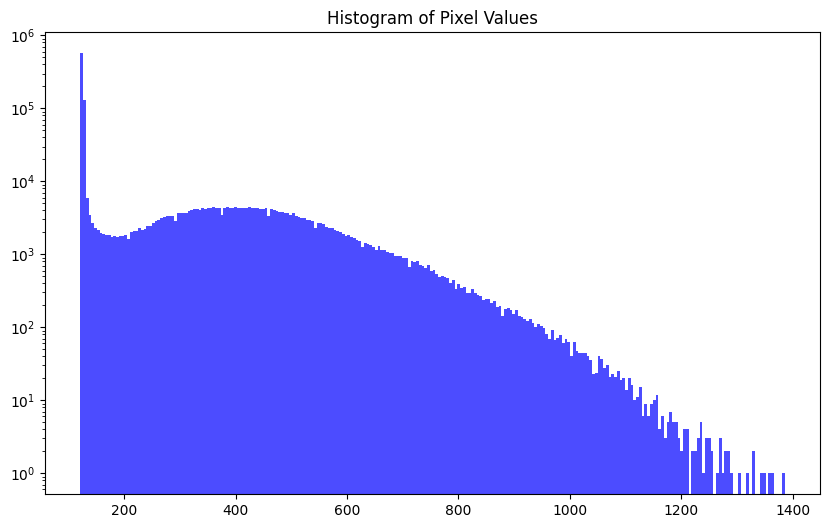

<Image layer 'Thresholded Image' at 0x22d48146110>

In [15]:
import os
from htmltools import img
from imaris_ims_file_reader import ims
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import napari
from scipy.ndimage import gaussian_filter

input_directory = r"C:\Users\6331823\Local SSD\Fixed intestinal H2B"
movie_path = os.path.join(input_directory, "Experiment_final_1_F06.ims")
image = ims(movie_path)[30]  # get the last frame and remove singleton dimensions
image = np.max(image, axis=0)
image = np.max(image, axis=0)  # max projection over Z
image = gaussian_filter(image, sigma=2)  # apply Gaussian filter to smooth the image
print(f"Image shape: {image.shape}")
print(np.median(image))

     # the valley
print(f"Threshold value: {t}")

image_values = image.flatten()
plt.figure(figsize=(10, 6))
plt.hist(image_values, bins=256, color='blue', alpha=0.7)
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Histogram of Pixel Values')
plt.show()

viewer = napari.Viewer(ndisplay=2)
viewer.add_image(image, name="Max Projection")
treshold_image = np.where(image > t, image, 0)
viewer.add_image(treshold_image, name="Thresholded Image")